In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
wc = 1.0 * 2 * np.pi  #cavity frequency
wa = 1.0 * 2 * np.pi  #atom frequency
g = 0.05 * 2 * np.pi  #coupling strength
kappa = 0.005  #cavity dissipation rate
gamma = 0.05  #atom/ qubit dissipation rate
N = 20  #number of cavity fock states
n_th = 0.0  #average number of thermal bath excitation
use_rwa = True
time = np.linspace(0,25,100)  #time evolution

In [3]:
#initial state
psi0 = tensor(basis(N,0), basis(2,1)) #start in the excited state(atom) and vacuum state(cavity)

#operators
a = tensor(destroy(N), qeye(2))  #annihilation operator on cavity
sigmam = tensor(qeye(N), destroy(2))  #annihilation operator on atom

#Hamiltonian
if use_rwa:
    H = wc * a.dag() * a + wa * sigmam.dag() * sigmam + g * (a.dag() * sigmam + a * sigmam.dag())
else:
    H = wc * a.dag() * a + wa * sigmam.dag() * sigmam + g * (a.dag() + a) * (sigmam.dag() + sigmam)

In [4]:
#collapse operators, describing dissipation
c_ops = []

#cavity relaxation/ decay
#if cavity coupled to a thermal bath, characterized by thermal noise n_th
#photon emitted to thermal bath
rate1 = kappa * (1 + n_th)
if rate1 > 0:
    c_ops.append(np.sqrt(rate1) * a)

#cavity excitation
#photon absorbed from thermal bath
rate2 = kappa * n_th
if rate2 > 0:
    c_ops.append(np.sqrt(rate2) * a.dag())

#atom relaxation/ decay
rate3 = gamma
if rate3 > 0:
    c_ops.append(np.sqrt(rate3) * sigmam)

#solve master equation
result = mesolve(H, psi0, time, c_ops, [a.dag() * a, sigmam.dag() * sigmam])
#return a.dag()*a and sigmam.dag()*sigmam expectation values               

E:\Anaconda\envs\qutip-env\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Text(0.5, 1.0, 'vacuum rabi oscillations')

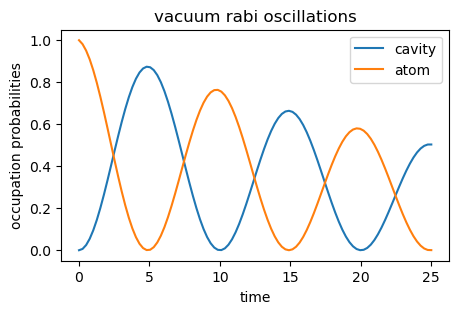

In [5]:
#vacuum rabi oscillations with dissipation
n_c = result.expect[0]  #expectation value for cavity occupation number
n_a = result.expect[1]  #expectation value for atom occupation number

fig, axe = plt.subplots(1,1, figsize = (5,3))
axe.plot(time, n_c, label = 'cavity')
axe.plot(time, n_a, label = 'atom')
axe.legend(loc = 0)
axe.set_xlabel('time')
axe.set_ylabel('occupation probabilities')
axe.set_title('vacuum rabi oscillations')

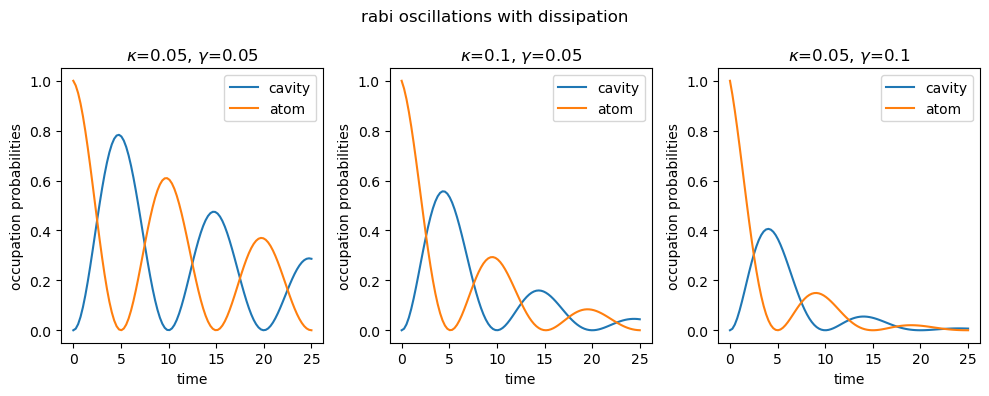

In [6]:
#change kappa and gamma, cavity and atom dissipation rate
c_ops1 = []
def cavity_dissipation(kappa):
    rate1 = kappa * (1 + n_th)
    if rate1 > 0:
        c_ops1.append(np.sqrt(rate1) * a)

def cavity_excitation(kappa):
    rate2 = kappa * n_th
    if rate2 > 0:
        c_ops1.append(np.sqrt(rate2) * a.dag())

def atom_dissipation(gamma):
    rate3 = gamma
    if rate3 > 0:
        c_ops1.append(np.sqrt(rate3) * sigmam)

def expectation_value(kappa, gamma):
    cavity_dissipation(kappa)
    cavity_excitation(kappa)
    atom_dissipation(gamma)
    result = mesolve(H, psi0, time, c_ops1, [a.dag() * a, sigmam.dag() * sigmam])
    n_c = result.expect[0]  #expectation value for cavity occupation number
    n_a = result.expect[1]  #expectation value for atom occupation number
    return n_c, n_a

n_c1, n_a1 = expectation_value(0.05, 0.05) #kappa = 0.05, gamma = 0.05
n_c2, n_a2 = expectation_value(0.1, 0.05)  #kappa = 0.1, gamma = 0.05
n_c3, n_a3 = expectation_value(0.05, 0.1)  #kappa = 0.05, gamma = 0.1
n_clist = [n_c1, n_c2, n_c3]
n_alist = [n_a1, n_a2, n_a3]

kappas = [0.05, 0.1, 0.05]
gammas = [0.05, 0.05, 0.1]

fig, axe = plt.subplots(1, 3, figsize = (10,4))
for i in range(0,3):
    axe[i].plot(time, n_clist[i], label = 'cavity')
    axe[i].plot(time, n_alist[i], label = 'atom')
    axe[i].legend(loc = 0)
    axe[i].set_xlabel('time')
    axe[i].set_ylabel('occupation probabilities')
    axe[i].set_title(f'$\kappa$={kappas[i]}, $\gamma$={gammas[i]}')
plt.suptitle('rabi oscillations with dissipation')
plt.tight_layout()